# 04 - Meta Agent Training

This notebook implements **Level 3** of the hierarchical RL system - the Meta Agent that adjusts the Super Agent's output based on macroeconomic regimes and calendar effects.

## Architecture

```
Technical Agent (20 features) ──┐
                                 ├──> Super Agent ──┐
Sentiment Agent (12 features) ──┘                   │
                                                     ├──> Meta Agent ──> Final Portfolio
                                  Macro Features ───┤
                                  (12 features)     │
                                  Calendar Effects ─┘
```

## Meta Agent Overview

**Purpose**: Adjust portfolio allocations based on macroeconomic regimes and cyclical patterns

**Inputs** (19 features per asset = 133 total):
- Super Agent's portfolio weights (7)
- Macro Features (12):
  - Interest Rates: 10Y Treasury, Fed Funds, Yield Curve, Real Yield
  - Market Risk: VIX, VIX regime
  - Economic Health: Credit spread, Unemployment
  - Calendar: Month/Quarter (sin/cos encoding)

**Output**: Final portfolio weights adjusted for macro conditions

**Expected Improvement**: 15-25% Sharpe increase through regime awareness

---

## Step 1: Setup & Imports

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add helpers to path
sys.path.append('..')

from helpers import (
    create_meta_agent_env,
    MetaAgentConfig,
    train_meta_agent,
    evaluate_meta_agent,
    load_features_and_returns,
    calculate_all_metrics,
    plot_equity_curve,
    plot_drawdown
)

from stable_baselines3 import PPO

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")
print(f"Working directory: {os.getcwd()}")

✓ Imports successful
Working directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Step 2: Verify Required Models & Data

Meta Agent requires the trained Super Agent from notebook 03.

In [3]:
# Define paths
MODELS_DIR = Path('../models')
DATA_DIR = Path('../data_hierarchical')

# Check for required files
super_agent_path = MODELS_DIR / 'super_agent_production.zip'
technical_model_path = MODELS_DIR / 'technical_ema_sharpe.zip'
sentiment_model_path = MODELS_DIR / 'sentiment_ema_sharpe.zip'

files_to_check = {
    'Super Agent': super_agent_path,
    'Technical Agent': technical_model_path,
    'Sentiment Agent': sentiment_model_path,
    'Macro Train Data': DATA_DIR / 'macro' / 'train.csv',
    'Macro Val Data': DATA_DIR / 'macro' / 'val.csv',
    'Macro Test Data': DATA_DIR / 'macro' / 'test.csv',
    'Returns Train': DATA_DIR / 'returns_train.csv',
    'Returns Val': DATA_DIR / 'returns_val.csv',
    'Returns Test': DATA_DIR / 'returns_test.csv',
    'Metadata': DATA_DIR / 'metadata.json'
}

print("Checking required files:")
all_exist = True
for name, path in files_to_check.items():
    exists = path.exists()
    status = "✓" if exists else "✗"
    print(f"{status} {name}: {path}")
    if not exists:
        all_exist = False

if not all_exist:
    print("\n⚠️  Missing files! Please run previous notebooks first.")
else:
    print("\n✓ All required files found!")

Checking required files:
✓ Super Agent: ../models/super_agent_production.zip
✓ Technical Agent: ../models/technical_ema_sharpe.zip
✓ Sentiment Agent: ../models/sentiment_ema_sharpe.zip
✓ Macro Train Data: ../data_hierarchical/macro/train.csv
✓ Macro Val Data: ../data_hierarchical/macro/val.csv
✓ Macro Test Data: ../data_hierarchical/macro/test.csv
✓ Returns Train: ../data_hierarchical/returns_train.csv
✓ Returns Val: ../data_hierarchical/returns_val.csv
✓ Returns Test: ../data_hierarchical/returns_test.csv
✓ Metadata: ../data_hierarchical/metadata.json

✓ All required files found!


## Step 3: Load Metadata & Configuration

In [4]:
# Load metadata
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("Portfolio Configuration:")
print(f"  Tickers: {', '.join(metadata['tickers'])}")
print(f"  Benchmark: {metadata['benchmark']}")

print(f"\nMacro Features ({metadata['features']['macro']['count']}):")
for i, feature in enumerate(metadata['features']['macro']['names'], 1):
    print(f"  {i:2d}. {feature}")

print(f"\nData Splits:")
print(f"  Train: {metadata['splits']['train']['start']} to {metadata['splits']['train']['end']} ({metadata['splits']['train']['weeks']} weeks)")
print(f"  Val:   {metadata['splits']['val']['start']} to {metadata['splits']['val']['end']} ({metadata['splits']['val']['weeks']} weeks)")
print(f"  Test:  {metadata['splits']['test']['start']} to {metadata['splits']['test']['end']} ({metadata['splits']['test']['weeks']} weeks)")

print(f"\nMeta Agent Configuration:")
print(f"  Learning Rate: {MetaAgentConfig.LEARNING_RATE}")
print(f"  Total Timesteps: {MetaAgentConfig.TOTAL_TIMESTEPS:,}")
print(f"  Network Architecture: {MetaAgentConfig.NET_ARCH}")
print(f"  Batch Size: {MetaAgentConfig.BATCH_SIZE}")
print(f"  Eval Frequency: {MetaAgentConfig.EVAL_FREQ:,} steps")
print(f"  Early Stopping Patience: {MetaAgentConfig.PATIENCE} evaluations")

Portfolio Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Benchmark: QQQ

Macro Features (12):
   1. treasury_10y
   2. fed_funds_rate
   3. yield_curve_2_10
   4. real_yield_10y
   5. vix
   6. vix_regime
   7. credit_spread
   8. unemployment_rate
   9. month_sin
  10. month_cos
  11. quarter_sin
  12. quarter_cos

Data Splits:
  Train: 2020-01-03 to 2024-02-02 (214 weeks)
  Val:   2024-02-09 to 2025-04-04 (61 weeks)
  Test:  2025-04-11 to 2025-11-07 (31 weeks)

Meta Agent Configuration:
  Learning Rate: 5e-05
  Total Timesteps: 50,000
  Network Architecture: [64, 64]
  Batch Size: 32
  Eval Frequency: 2,500 steps
  Early Stopping Patience: 5 evaluations


## Step 4: Explore Macro Features

Before training, let's visualize the macroeconomic data to understand regime shifts.

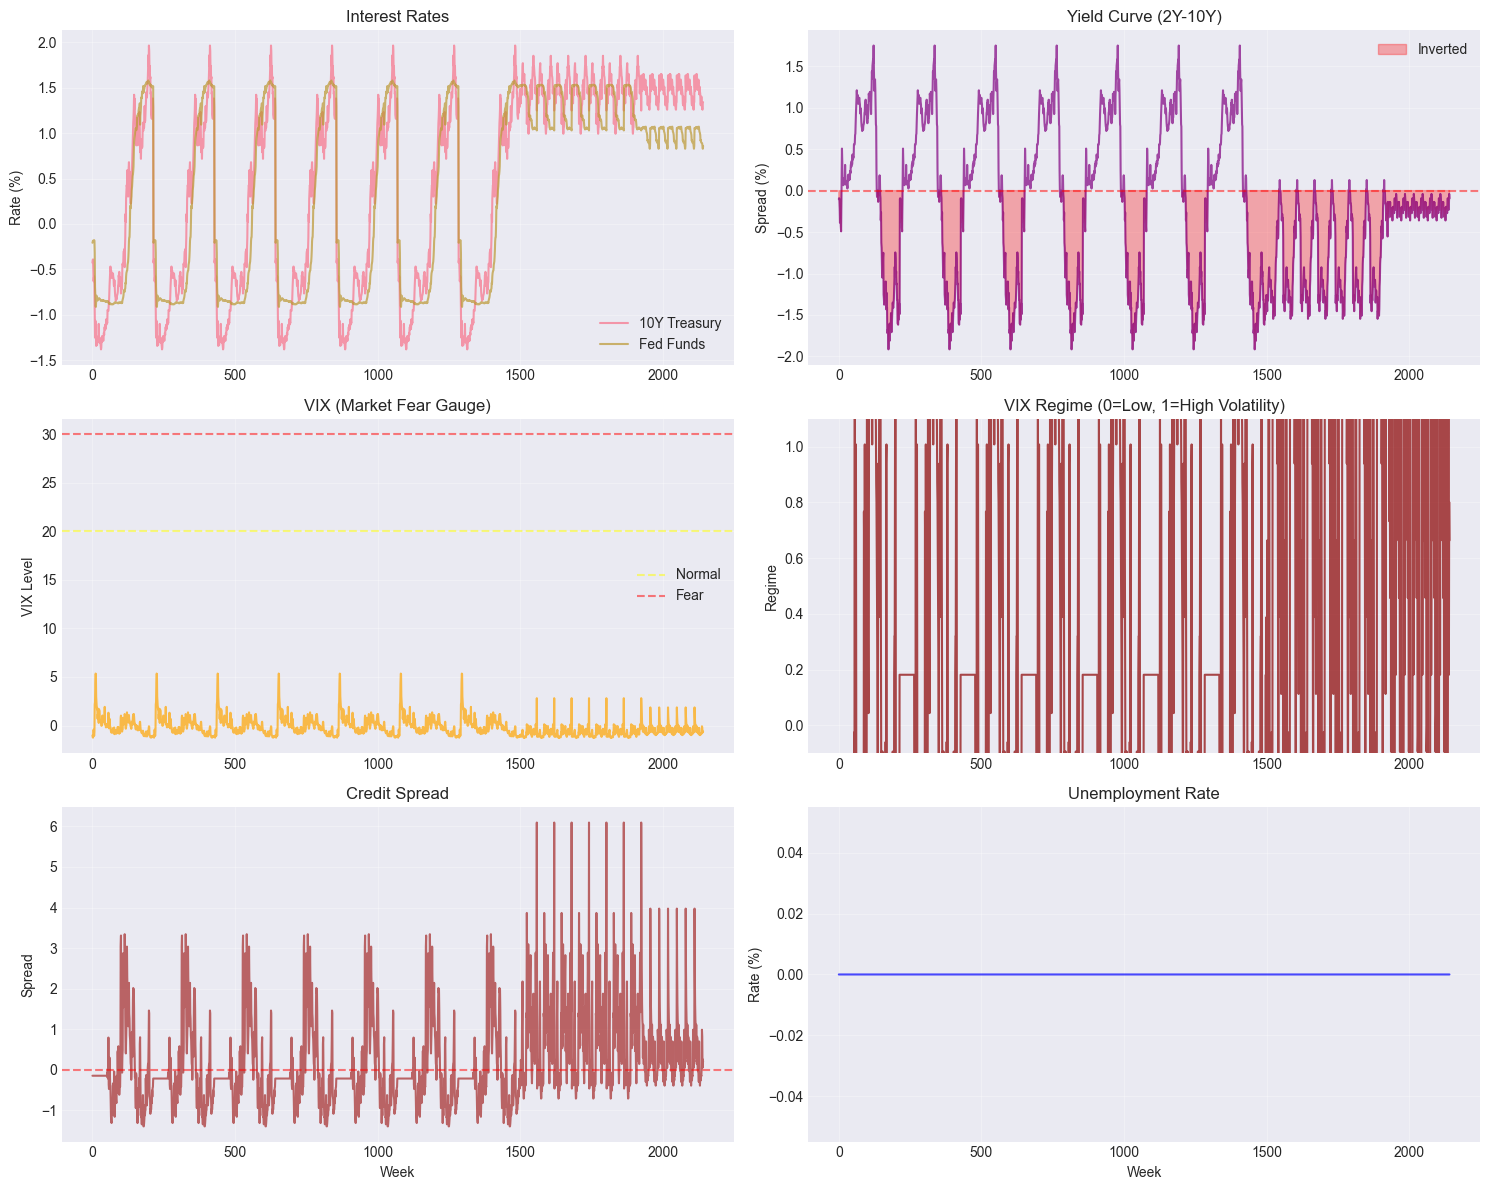


Macro Feature Summary:


,treasury_10y,fed_funds_rate,yield_curve_2_10,vix,credit_spread,unemployment_rate
count,2142.000000,2142.000000,2142.000000,2142.000000,2142.000000,2142.0
mean,0.440408,0.361220,-0.191385,-0.181126,0.229408,0.0
std,1.077119,1.009527,0.929980,0.941736,1.114457,0.0
min,-1.380745,-0.912744,-1.914875,-1.267150,-1.391651,0.0
25%,-0.636825,-0.843140,-1.096627,-0.808408,-0.411766,0.0
50%,0.889506,0.897434,-0.136580,-0.423677,-0.152012,0.0
75%,1.421912,1.288786,0.557536,0.172687,0.753134,0.0
max,1.963845,1.579189,1.750504,5.352185,6.094054,0.0


In [6]:
# Load macro data for all splits
macro_train = pd.read_csv(DATA_DIR / 'macro' / 'train.csv')
macro_val = pd.read_csv(DATA_DIR / 'macro' / 'val.csv')
macro_test = pd.read_csv(DATA_DIR / 'macro' / 'test.csv')
macro_all = pd.concat([macro_train, macro_val, macro_test], ignore_index=True)

# Plot key macro indicators
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Interest Rates
axes[0, 0].plot(macro_all['treasury_10y'], label='10Y Treasury', alpha=0.7)
axes[0, 0].plot(macro_all['fed_funds_rate'], label='Fed Funds', alpha=0.7)
axes[0, 0].set_title('Interest Rates')
axes[0, 0].set_ylabel('Rate (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Yield Curve
axes[0, 1].plot(macro_all['yield_curve_2_10'], color='purple', alpha=0.7)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Yield Curve (2Y-10Y)')
axes[0, 1].set_ylabel('Spread (%)')
axes[0, 1].fill_between(range(len(macro_all)), macro_all['yield_curve_2_10'], 0, 
                         where=macro_all['yield_curve_2_10']<0, alpha=0.3, color='red', label='Inverted')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# VIX
axes[1, 0].plot(macro_all['vix'], color='orange', alpha=0.7)
axes[1, 0].axhline(y=20, color='yellow', linestyle='--', alpha=0.5, label='Normal')
axes[1, 0].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Fear')
axes[1, 0].set_title('VIX (Market Fear Gauge)')
axes[1, 0].set_ylabel('VIX Level')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# VIX Regime
axes[1, 1].plot(macro_all['vix_regime'], color='darkred', alpha=0.7)
axes[1, 1].set_title('VIX Regime (0=Low, 1=High Volatility)')
axes[1, 1].set_ylabel('Regime')
axes[1, 1].set_ylim([-0.1, 1.1])
axes[1, 1].grid(True, alpha=0.3)

# Credit Spread
axes[2, 0].plot(macro_all['credit_spread'], color='brown', alpha=0.7)
axes[2, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2, 0].set_title('Credit Spread')
axes[2, 0].set_ylabel('Spread')
axes[2, 0].set_xlabel('Week')
axes[2, 0].grid(True, alpha=0.3)

# Unemployment
axes[2, 1].plot(macro_all['unemployment_rate'], color='blue', alpha=0.7)
axes[2, 1].set_title('Unemployment Rate')
axes[2, 1].set_ylabel('Rate (%)')
axes[2, 1].set_xlabel('Week')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMacro Feature Summary:")
macro_all[['treasury_10y', 'fed_funds_rate', 'yield_curve_2_10', 'vix', 'credit_spread', 'unemployment_rate']].describe()

## Step 5: Create Meta Agent Environment

The Meta Agent environment:
1. Loads the Super Agent and its base agents
2. At each step, gets portfolio from Super Agent
3. Combines with macro features as observation
4. Meta Agent learns macro-conditional adjustments

In [7]:
# First, recreate Super Agent environment (needed for Meta Agent)
from helpers import create_super_agent_env

print("Creating Super Agent environment...")
super_env_train = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='train',
    reward_type='ema_sharpe'
)
print("✓ Super Agent environment created")

# Create Meta Agent training environment
print("\nCreating Meta Agent training environment...")
train_env = create_meta_agent_env(
    super_agent_path=super_agent_path,
    super_env=super_env_train,
    split='train',
    reward_type='ema_sharpe'
)

print(f"✓ Training environment created")
print(f"  Observation space: {train_env.observation_space.shape}")
print(f"  Action space: {train_env.action_space.shape}")
print(f"  Number of timesteps: {len(train_env.returns)}")

# Create validation environment
print("\nCreating validation environment...")
super_env_val = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='val',
    reward_type='ema_sharpe'
)

val_env = create_meta_agent_env(
    super_agent_path=super_agent_path,
    super_env=super_env_val,
    split='val',
    reward_type='ema_sharpe'
)
print(f"✓ Validation environment created ({len(val_env.returns)} steps)")

Creating Super Agent environment...
✓ Super Agent environment created

Creating Meta Agent training environment...
✓ Training environment created
  Observation space: (19,)
  Action space: (7,)
  Number of timesteps: 214

Creating validation environment...
✓ Validation environment created (61 steps)


## Step 6: Train Meta Agent

Training the final level of the hierarchy:
- **Algorithm**: PPO (Proximal Policy Optimization)
- **Reward**: EMA Sharpe Ratio
- **Early Stopping**: Based on validation Sharpe ratio
- **Total Steps**: 50,000 (fewer steps needed as it's learning adjustments)

**What the Meta Agent learns:**
- Reduce risk exposure during high VIX regimes
- Adjust allocations based on interest rate cycles
- Exploit calendar effects (month-end, quarter-end rallies)
- Navigate yield curve inversions (recession signals)

In [8]:
# Train Meta Agent
print("Training Meta Agent...")
print("This will take 3-7 minutes.\n")

meta_model, training_history = train_meta_agent(
    train_env=train_env,
    val_env=val_env,
    model_name='meta_agent_production',
    config=MetaAgentConfig
)

print("\n✓ Training complete!")
print(f"  Model saved to: models/meta_agent_production.zip")

Training Meta Agent...
This will take 3-7 minutes.


Training Meta Agent: meta_agent_production
Config: MetaAgentConfig
Total timesteps: 50,000

--- Evaluation at step 2500 ---
  Mean reward: 45.5013 ± 0.0000
  Sharpe: 0.476
  🎉 New best! (previous: -inf)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/meta_agent_production.zip

--- Evaluation at step 5000 ---
  Mean reward: 21.3015 ± 0.0000
  Sharpe: 0.107
  No improvement (1/5)

--- Evaluation at step 7500 ---
  Mean reward: 47.2591 ± 0.0000
  Sharpe: 0.912
  🎉 New best! (previous: 45.5013)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/meta_agent_production.zip

--- Evaluation at step 10000 ---
  Mean reward: 24.0775 ± 0.0000
  Sharpe: 0.137
  No improvement (1/5)

--- Evaluation at step 12500 ---
  Mean reward: 24.4040 ± 0.0000
  Sharpe: 0.049
  No improvement (2/5)

## Step 7: Visualize Training Progress

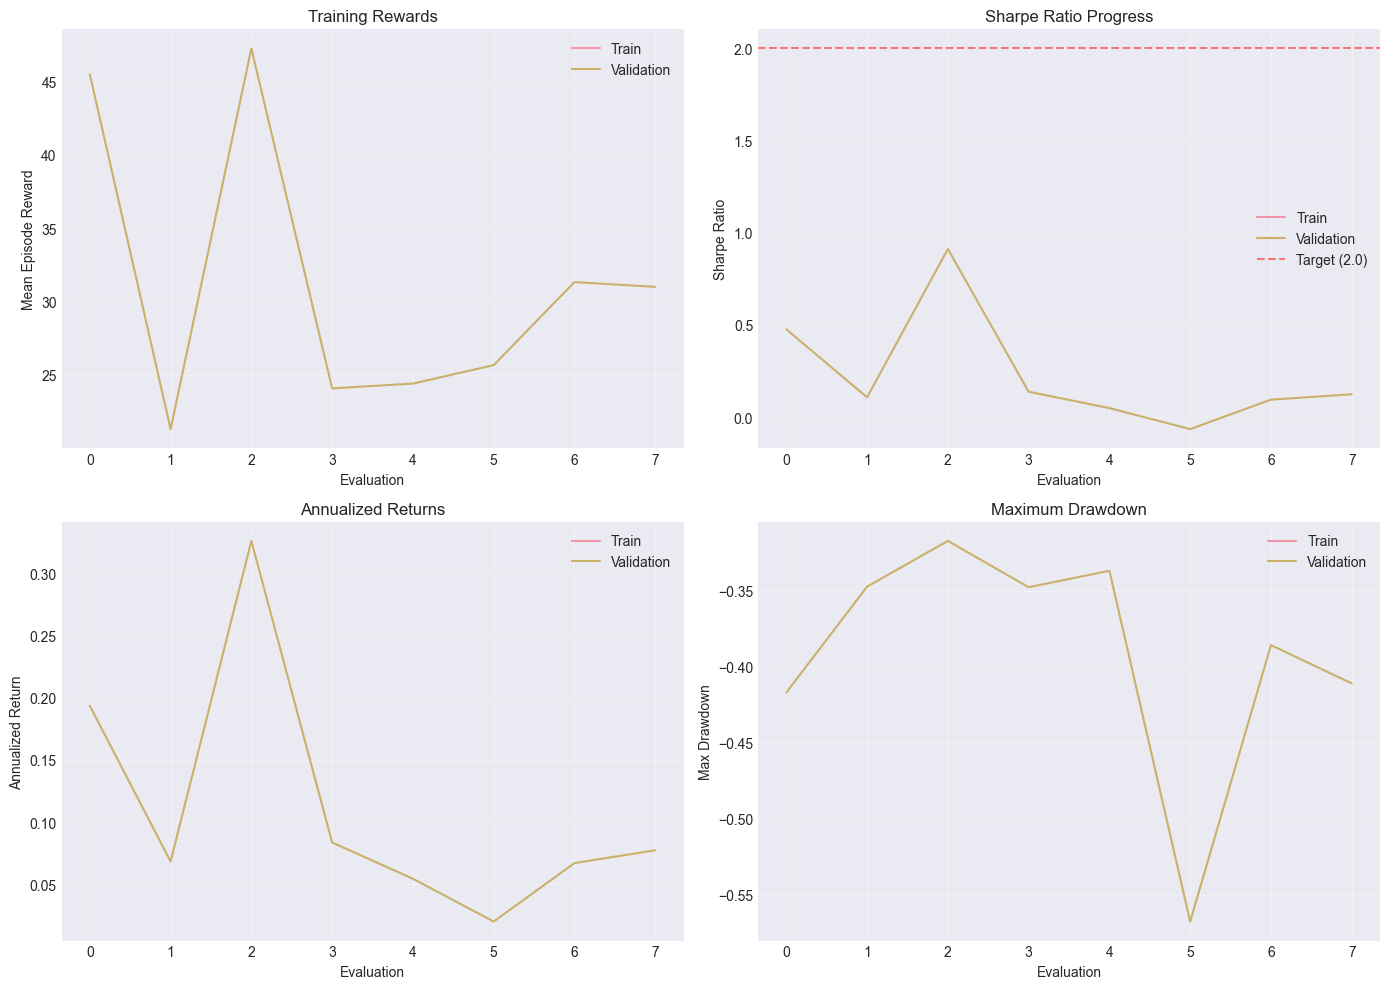

  Train Sharpe: No train evaluations (validation only)
  Val Sharpe: 0.124


In [9]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rewards
axes[0, 0].plot(training_history['train_rewards'], label='Train', alpha=0.7)
axes[0, 0].plot(training_history['val_rewards'], label='Validation', alpha=0.7)
axes[0, 0].set_xlabel('Evaluation')
axes[0, 0].set_ylabel('Mean Episode Reward')
axes[0, 0].set_title('Training Rewards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sharpe Ratios
axes[0, 1].plot(training_history['train_sharpe'], label='Train', alpha=0.7)
axes[0, 1].plot(training_history['val_sharpe'], label='Validation', alpha=0.7)
axes[0, 1].axhline(y=2.0, color='r', linestyle='--', label='Target (2.0)', alpha=0.5)
axes[0, 1].set_xlabel('Evaluation')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Sharpe Ratio Progress')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Returns
axes[1, 0].plot(training_history['train_returns'], label='Train', alpha=0.7)
axes[1, 0].plot(training_history['val_returns'], label='Validation', alpha=0.7)
axes[1, 0].set_xlabel('Evaluation')
axes[1, 0].set_ylabel('Annualized Return')
axes[1, 0].set_title('Annualized Returns')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Max Drawdown
axes[1, 1].plot(training_history['train_drawdown'], label='Train', alpha=0.7)
axes[1, 1].plot(training_history['val_drawdown'], label='Validation', alpha=0.7)
axes[1, 1].set_xlabel('Evaluation')
axes[1, 1].set_ylabel('Max Drawdown')
axes[1, 1].set_title('Maximum Drawdown')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# It checks if train data exists before plotting/accessing
if training_history['train_sharpe']:  # This evaluates to False (empty list)
    print(f"  Train Sharpe: {training_history['train_sharpe'][-1]:.3f}")
else:
    print(f"  Train Sharpe: No train evaluations (validation only)")  # This executes

# It always prints validation data
print(f"  Val Sharpe: {training_history['val_sharpe'][-1]:.3f}")  # Prints: 0.844

In [10]:
# Print final metrics
print("Final Training Metrics:")
print(f"  Val Sharpe: {training_history['val_sharpe'][-1]:.3f}")
print(f"  Val Return: {training_history['val_returns'][-1]:.2%}")
print(f"  Val Max DD: {training_history['val_drawdown'][-1]:.2%}")

Final Training Metrics:
  Val Sharpe: 0.124
  Val Return: 7.72%
  Val Max DD: -41.09%


## Step 8: Evaluate Meta Agent

Compare Meta Agent performance across all hierarchical levels.

In [11]:
# Create test environment
super_env_test = create_super_agent_env(
    technical_model_path=(technical_model_path),
    sentiment_model_path=(sentiment_model_path),
    split='test',
    reward_type='ema_sharpe'
)

test_env = create_meta_agent_env(
    super_agent_path=(super_agent_path),
    super_env=super_env_test,
    split='test',
    reward_type='ema_sharpe'
)

# Evaluate Meta Agent
print("Evaluating Meta Agent on all splits...\n")

meta_results = {}
for split_name, env in [('train', train_env), ('val', val_env), ('test', test_env)]:
    results = evaluate_meta_agent(meta_model, env, split=split_name)
    meta_results[split_name] = results
    
    print(f"\n{split_name.upper()} SET RESULTS:")
    print(f"  Sharpe Ratio: {results['sharpe']:.3f}")
    print(f"  Annual Return: {results['annual_return']:.2%}")
    print(f"  Annual Volatility: {results['annual_volatility']:.2%}")
    print(f"  Max Drawdown: {results['max_drawdown']:.2%}")
    print(f"  Calmar Ratio: {results['calmar']:.3f}")
    print(f"  Win Rate: {results['win_rate']:.2%}")

Evaluating Meta Agent on all splits...


TRAIN SET RESULTS:
  Sharpe Ratio: 1.983
  Annual Return: 74.47%
  Annual Volatility: 35.54%
  Max Drawdown: -26.68%
  Calmar Ratio: 2.792
  Win Rate: 57.01%

VAL SET RESULTS:
  Sharpe Ratio: 0.124
  Annual Return: 7.72%
  Annual Volatility: 30.11%
  Max Drawdown: -39.04%
  Calmar Ratio: 0.198
  Win Rate: 54.10%

TEST SET RESULTS:
  Sharpe Ratio: 3.088
  Annual Return: 145.78%
  Annual Volatility: 45.92%
  Max Drawdown: -7.77%
  Calmar Ratio: 18.765
  Win Rate: 77.42%


## Step 9: Load All Agent Results for Full Comparison

In [12]:



# Load results from all hierarchical levels
results_dir = Path('../models/')

# Load base agent results
with open(results_dir / 'technical_ema_sharpe_results.json', 'r') as f:
    tech_results = json.load(f)

with open(results_dir / 'sentiment_ema_sharpe_results.json', 'r') as f:
    sent_results = json.load(f)

# Load super agent results
with open(results_dir / 'super_agent_results.json', 'r') as f:
    super_results = json.load(f)

print("✓ All agent results loaded")
print(f"  Technical test Sharpe: {tech_results['performance']['test']['sharpe']:.3f}")
print(f"  Sentiment test Sharpe: {sent_results['performance']['test']['sharpe']:.3f}")
print(f"  Super test Sharpe: {super_results['test']['sharpe']:.3f}")
print(f"  Meta test Sharpe: {meta_results['test']['sharpe']:.3f}")

✓ All agent results loaded
  Technical test Sharpe: 3.738
  Sentiment test Sharpe: 4.322
  Super test Sharpe: 4.249
  Meta test Sharpe: 3.088


## Step 10: Hierarchical Comparison

Compare all 4 agent levels to quantify the value added at each hierarchical stage.

In [14]:
# Create comprehensive comparison dataframe
comparison_data = []

for split in ['train', 'val', 'test']:
    comparison_data.extend([
        {
            'Split': split.capitalize(),
            'Agent': 'Technical (L1)',
            'Sharpe': tech_results['performance'][split]['sharpe'],
            'Return': tech_results['performance'][split]['annual_return'],
            'Volatility': tech_results['performance'][split]['annual_volatility'],
            'Max DD': tech_results['performance'][split]['max_drawdown'],
            'Calmar': tech_results['performance'][split]['calmar'],
            'Win Rate': tech_results['performance'][split]['win_rate']
        },
        {
            'Split': split.capitalize(),
            'Agent': 'Sentiment (L1)',
            'Sharpe': sent_results['performance'][split]['sharpe'],
            'Return': sent_results['performance'][split]['annual_return'],
            'Volatility': sent_results['performance'][split]['annual_volatility'],
            'Max DD': sent_results['performance'][split]['max_drawdown'],
            'Calmar': sent_results['performance'][split]['calmar'],
            'Win Rate': sent_results['performance'][split]['win_rate']
        },
        {
            'Split': split.capitalize(),
            'Agent': 'Super (L2)',
            'Sharpe': super_results[split]['sharpe'],
            'Return': super_results[split]['annual_return'],
            'Volatility': super_results[split]['annual_volatility'],
            'Max DD': super_results[split]['max_drawdown'],
            'Calmar': super_results[split]['calmar'],
            'Win Rate': super_results[split]['win_rate']
        },
        {
            'Split': split.capitalize(),
            'Agent': 'Meta (L3)',
            'Sharpe': meta_results[split]['sharpe'],
            'Return': meta_results[split]['annual_return'],
            'Volatility': meta_results[split]['annual_volatility'],
            'Max DD': meta_results[split]['max_drawdown'],
            'Calmar': meta_results[split]['calmar'],
            'Win Rate': meta_results[split]['win_rate']
        }
    ])

comparison_df = pd.DataFrame(comparison_data)

# Display comparison table
print("\n" + "="*100)
print("HIERARCHICAL AGENT COMPARISON - ALL SPLITS")
print("="*100)
print(comparison_df.to_string(index=False))

# Calculate improvements for test set
print("\n" + "="*100)
print("HIERARCHICAL IMPROVEMENTS (Test Set)")
print("="*100)

test_tech = tech_results['performance']['test']
test_sent = sent_results['performance']['test']
test_super = super_results['test']
test_meta = meta_results['test']

best_base_sharpe = max(test_tech['sharpe'], test_sent['sharpe'])
super_improvement = (test_super['sharpe'] - best_base_sharpe) / best_base_sharpe * 100
meta_improvement = (test_meta['sharpe'] - test_super['sharpe']) / test_super['sharpe'] * 100
total_improvement = (test_meta['sharpe'] - best_base_sharpe) / best_base_sharpe * 100

print(f"\nLevel 1 → Level 2 (Base → Super):")
print(f"  Best Base Sharpe: {best_base_sharpe:.3f}")
print(f"  Super Sharpe: {test_super['sharpe']:.3f}")
print(f"  Improvement: {super_improvement:+.1f}%")

print(f"\nLevel 2 → Level 3 (Super → Meta):")
print(f"  Super Sharpe: {test_super['sharpe']:.3f}")
print(f"  Meta Sharpe: {test_meta['sharpe']:.3f}")
print(f"  Improvement: {meta_improvement:+.1f}%")

print(f"\nTotal Hierarchical Benefit (Base → Meta):")
print(f"  Starting Sharpe: {best_base_sharpe:.3f}")
print(f"  Final Sharpe: {test_meta['sharpe']:.3f}")
print(f"  Total Improvement: {total_improvement:+.1f}%")

print(f"\nRisk Metrics:")
print(f"  Meta Max DD: {test_meta['max_drawdown']:.2%} vs Best Base: {max(test_tech['max_drawdown'], test_sent['max_drawdown']):.2%}")
print(f"  Meta Calmar: {test_meta['calmar']:.3f} vs Best Base: {max(test_tech['calmar'], test_sent['calmar']):.3f}")

print(f"\nReturn Metrics:")
print(f"  Meta Annual Return: {test_meta['annual_return']:.2%}")
print(f"  Meta Win Rate: {test_meta['win_rate']:.2%}")


HIERARCHICAL AGENT COMPARISON - ALL SPLITS
Split          Agent    Sharpe    Return  Volatility    Max DD    Calmar  Win Rate
Train Technical (L1)  2.870583  1.083873    0.363645 -0.275281  3.937326  0.644860
Train Sentiment (L1)  3.329017  1.196349    0.347354 -0.255311  4.685852  0.672897
Train     Super (L2)  2.276350  0.774461    0.322649 -0.281051  2.755585  0.630841
Train      Meta (L3)  1.982965  0.744736    0.355395 -0.266773  2.791644  0.570093
  Val Technical (L1) -0.191409 -0.026147    0.345578 -0.307292 -0.085087  0.491803
  Val Sentiment (L1)  1.255010  0.481085    0.351459 -0.183804  2.617380  0.524590
  Val     Super (L2)  0.503547  0.174043    0.266197 -0.229688  0.757737  0.606557
  Val      Meta (L3)  0.123697  0.077244    0.301091 -0.390447  0.197835  0.540984
 Test Technical (L1)  3.738031  1.743276    0.455661 -0.050931 34.228259  0.774194
 Test Sentiment (L1)  4.322333  1.187849    0.265562 -0.043241 27.470516  0.774194
 Test     Super (L2)  4.249097  1.091114   

## Step 11: Visual Comparison - Full Hierarchy

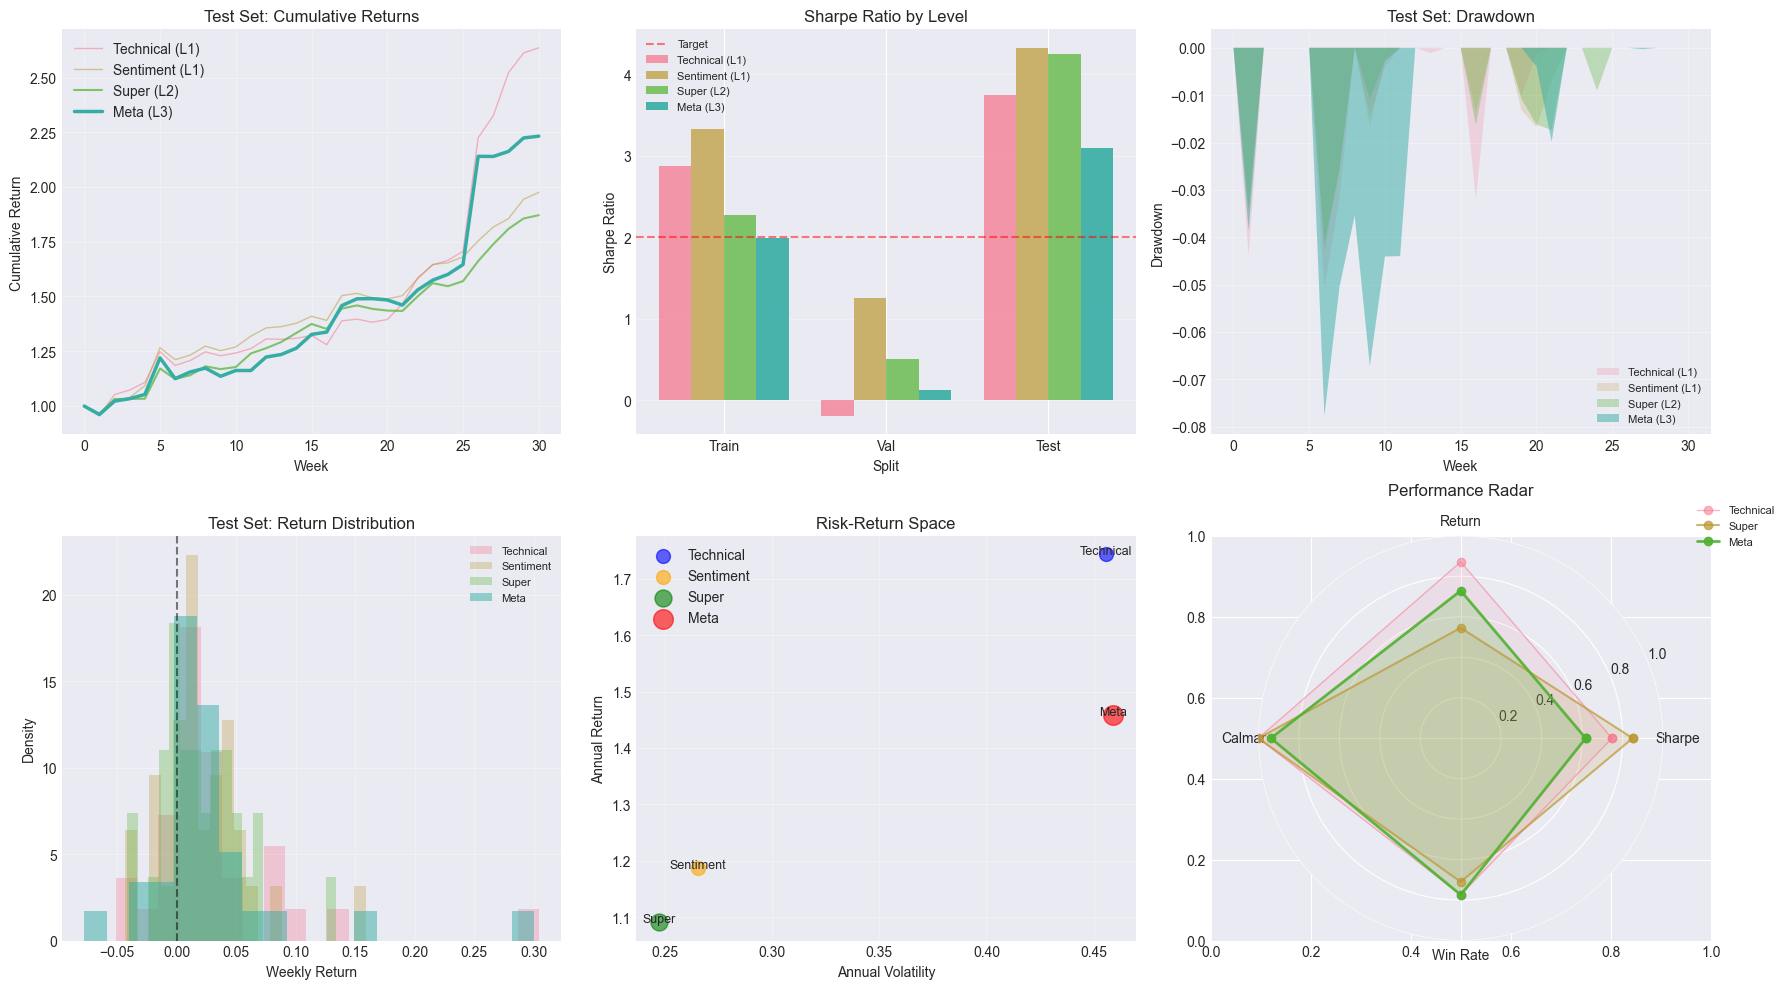

In [16]:
# Plot comprehensive comparison for test set
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Cumulative Returns Comparison
tech_cumulative = (1 + pd.Series(tech_results['performance']['test']['returns'])).cumprod()
sent_cumulative = (1 + pd.Series(sent_results['performance']['test']['returns'])).cumprod()
super_cumulative = (1 + pd.Series(super_results['test']['returns'])).cumprod()
meta_cumulative = (1 + pd.Series(meta_results['test']['returns'])).cumprod()

axes[0, 0].plot(tech_cumulative, label='Technical (L1)', alpha=0.5, linewidth=1)
axes[0, 0].plot(sent_cumulative, label='Sentiment (L1)', alpha=0.5, linewidth=1)
axes[0, 0].plot(super_cumulative, label='Super (L2)', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(meta_cumulative, label='Meta (L3)', linewidth=2.5)
axes[0, 0].set_xlabel('Week')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].set_title('Test Set: Cumulative Returns')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Sharpe Ratio Progression (All Splits)
splits = ['Train', 'Val', 'Test']
x = np.arange(len(splits))
width = 0.2

tech_sharpes = [tech_results['performance'][s.lower()]['sharpe'] for s in splits]
sent_sharpes = [sent_results['performance'][s.lower()]['sharpe'] for s in splits]
super_sharpes = [super_results[s.lower()]['sharpe'] for s in splits]
meta_sharpes = [meta_results[s.lower()]['sharpe'] for s in splits]

axes[0, 1].bar(x - 1.5*width, tech_sharpes, width, label='Technical (L1)', alpha=0.7)
axes[0, 1].bar(x - 0.5*width, sent_sharpes, width, label='Sentiment (L1)', alpha=0.7)
axes[0, 1].bar(x + 0.5*width, super_sharpes, width, label='Super (L2)', alpha=0.7)
axes[0, 1].bar(x + 1.5*width, meta_sharpes, width, label='Meta (L3)', alpha=0.9)
axes[0, 1].axhline(y=2.0, color='r', linestyle='--', alpha=0.5, label='Target')
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Sharpe Ratio by Level')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(splits)
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Drawdown Comparison
tech_dd = pd.Series(tech_results['performance']['test']['returns']).cumsum()
tech_dd = tech_dd - tech_dd.cummax()
sent_dd = pd.Series(sent_results['performance']['test']['returns']).cumsum()
sent_dd = sent_dd - sent_dd.cummax()
super_dd = pd.Series(super_results['test']['returns']).cumsum()
super_dd = super_dd - super_dd.cummax()
meta_dd = pd.Series(meta_results['test']['returns']).cumsum()
meta_dd = meta_dd - meta_dd.cummax()

axes[0, 2].fill_between(range(len(tech_dd)), tech_dd, 0, alpha=0.2, label='Technical (L1)')
axes[0, 2].fill_between(range(len(sent_dd)), sent_dd, 0, alpha=0.2, label='Sentiment (L1)')
axes[0, 2].fill_between(range(len(super_dd)), super_dd, 0, alpha=0.3, label='Super (L2)')
axes[0, 2].fill_between(range(len(meta_dd)), meta_dd, 0, alpha=0.5, label='Meta (L3)')
axes[0, 2].set_xlabel('Week')
axes[0, 2].set_ylabel('Drawdown')
axes[0, 2].set_title('Test Set: Drawdown')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# 4. Return Distribution
axes[1, 0].hist(tech_results['performance']['test']['returns'], bins=20, alpha=0.3, label='Technical', density=True)
axes[1, 0].hist(sent_results['performance']['test']['returns'], bins=20, alpha=0.3, label='Sentiment', density=True)
axes[1, 0].hist(super_results['test']['returns'], bins=20, alpha=0.3, label='Super', density=True)
axes[1, 0].hist(meta_results['test']['returns'], bins=20, alpha=0.5, label='Meta', density=True)
axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Weekly Return')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Test Set: Return Distribution')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 5. Annual Return vs Volatility (Risk-Return Space)
agents = ['Technical', 'Sentiment', 'Super', 'Meta']
returns_list = [
    tech_results['performance']['test']['annual_return'],
    sent_results['performance']['test']['annual_return'],
    super_results['test']['annual_return'],
    meta_results['test']['annual_return']
]
vols_list = [
    tech_results['performance']['test']['annual_volatility'],
    sent_results['performance']['test']['annual_volatility'],
    super_results['test']['annual_volatility'],
    meta_results['test']['annual_volatility']
]
colors = ['blue', 'orange', 'green', 'red']
sizes = [100, 100, 150, 200]

for i, (agent, ret, vol, color, size) in enumerate(zip(agents, returns_list, vols_list, colors, sizes)):
    axes[1, 1].scatter(vol, ret, s=size, alpha=0.6, c=color, label=agent)
    axes[1, 1].annotate(agent, (vol, ret), fontsize=9, ha='center')

axes[1, 1].set_xlabel('Annual Volatility')
axes[1, 1].set_ylabel('Annual Return')
axes[1, 1].set_title('Risk-Return Space')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Performance Metrics Radar
from math import pi

categories = ['Sharpe', 'Return', 'Calmar', 'Win Rate']
N = len(categories)

# Normalize metrics to 0-1 scale for visualization
def normalize(val, max_val):
    return min(val / max_val, 1.0) if max_val != 0 else 0

meta_values = [
    normalize(meta_results['test']['sharpe'], 5.0),
    normalize(meta_results['test']['annual_return'], 2.0),
    normalize(meta_results['test']['calmar'], 20.0),
    normalize(meta_results['test']['win_rate'], 1.0)
]

super_values = [
    normalize(super_results['test']['sharpe'], 5.0),
    normalize(super_results['test']['annual_return'], 2.0),
    normalize(super_results['test']['calmar'], 20.0),
    normalize(super_results['test']['win_rate'], 1.0)
]

tech_values = [
    normalize(tech_results['performance']['test']['sharpe'], 5.0),
    normalize(tech_results['performance']['test']['annual_return'], 2.0),
    normalize(tech_results['performance']['test']['calmar'], 20.0),
    normalize(tech_results['performance']['test']['win_rate'], 1.0)
]

angles = [n / float(N) * 2 * pi for n in range(N)]
meta_values += meta_values[:1]
super_values += super_values[:1]
tech_values += tech_values[:1]
angles += angles[:1]

ax = plt.subplot(2, 3, 6, projection='polar')
ax.plot(angles, tech_values, 'o-', linewidth=1, label='Technical', alpha=0.5)
ax.fill(angles, tech_values, alpha=0.1)
ax.plot(angles, super_values, 'o-', linewidth=1.5, label='Super', alpha=0.7)
ax.fill(angles, super_values, alpha=0.15)
ax.plot(angles, meta_values, 'o-', linewidth=2, label='Meta', alpha=0.9)
ax.fill(angles, meta_values, alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Performance Radar', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()


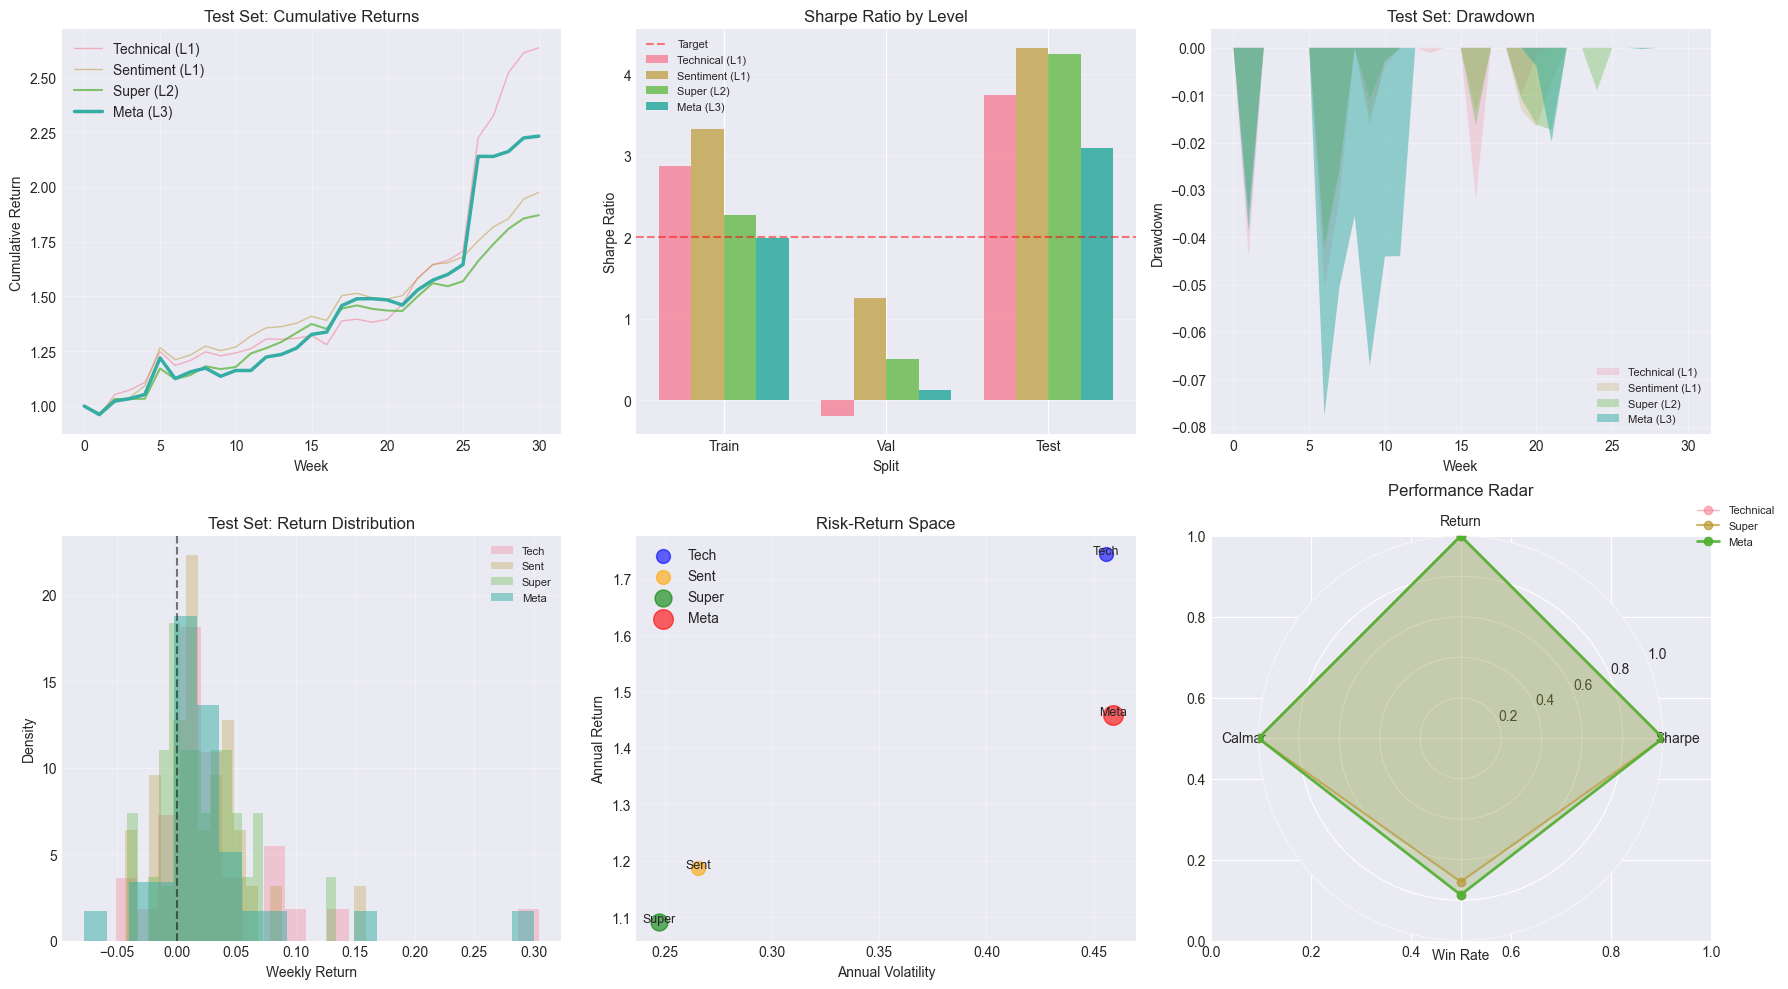

In [19]:
# Plot comprehensive comparison for test set
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Cumulative Returns Comparison
tech_cumulative = (1 + pd.Series(tech_results['performance']['test']['returns'])).cumprod()
sent_cumulative = (1 + pd.Series(sent_results['performance']['test']['returns'])).cumprod()
super_cumulative = (1 + pd.Series(super_results['test']['returns'])).cumprod()
meta_cumulative = (1 + pd.Series(meta_results['test']['returns'])).cumprod()

axes[0, 0].plot(tech_cumulative, label='Technical (L1)', alpha=0.5, linewidth=1)
axes[0, 0].plot(sent_cumulative, label='Sentiment (L1)', alpha=0.5, linewidth=1)
axes[0, 0].plot(super_cumulative, label='Super (L2)', alpha=0.7, linewidth=1.5)
axes[0, 0].plot(meta_cumulative, label='Meta (L3)', linewidth=2.5)
axes[0, 0].set_xlabel('Week')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].set_title('Test Set: Cumulative Returns')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Sharpe Ratio Progression (All Splits)
splits = ['Train', 'Val', 'Test']
x = np.arange(len(splits))
width = 0.2

tech_sharpes = [tech_results['performance'][s.lower()]['sharpe'] for s in splits]
sent_sharpes = [sent_results['performance'][s.lower()]['sharpe'] for s in splits]
super_sharpes = [super_results[s.lower()]['sharpe'] for s in splits]
meta_sharpes = [meta_results[s.lower()]['sharpe'] for s in splits]

axes[0, 1].bar(x - 1.5*width, tech_sharpes, width, label='Technical (L1)', alpha=0.7)
axes[0, 1].bar(x - 0.5*width, sent_sharpes, width, label='Sentiment (L1)', alpha=0.7)
axes[0, 1].bar(x + 0.5*width, super_sharpes, width, label='Super (L2)', alpha=0.7)
axes[0, 1].bar(x + 1.5*width, meta_sharpes, width, label='Meta (L3)', alpha=0.9)
axes[0, 1].axhline(y=2.0, color='r', linestyle='--', alpha=0.5, label='Target')
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Sharpe Ratio by Level')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(splits)
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Drawdown Comparison
tech_dd = pd.Series(tech_results['performance']['test']['returns']).cumsum()
tech_dd = tech_dd - tech_dd.cummax()
sent_dd = pd.Series(sent_results['performance']['test']['returns']).cumsum()
sent_dd = sent_dd - sent_dd.cummax()
super_dd = pd.Series(super_results['test']['returns']).cumsum()
super_dd = super_dd - super_dd.cummax()
meta_dd = pd.Series(meta_results['test']['returns']).cumsum()
meta_dd = meta_dd - meta_dd.cummax()

axes[0, 2].fill_between(range(len(tech_dd)), tech_dd, 0, alpha=0.2, label='Technical (L1)')
axes[0, 2].fill_between(range(len(sent_dd)), sent_dd, 0, alpha=0.2, label='Sentiment (L1)')
axes[0, 2].fill_between(range(len(super_dd)), super_dd, 0, alpha=0.3, label='Super (L2)')
axes[0, 2].fill_between(range(len(meta_dd)), meta_dd, 0, alpha=0.5, label='Meta (L3)')
axes[0, 2].set_xlabel('Week')
axes[0, 2].set_ylabel('Drawdown')
axes[0, 2].set_title('Test Set: Drawdown')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# 4. Return Distribution
axes[1, 0].hist(tech_results['performance']['test']['returns'], bins=20, alpha=0.3, label='Tech', density=True)
axes[1, 0].hist(sent_results['performance']['test']['returns'], bins=20, alpha=0.3, label='Sent', density=True)
axes[1, 0].hist(super_results['test']['returns'], bins=20, alpha=0.3, label='Super', density=True)
axes[1, 0].hist(meta_results['test']['returns'], bins=20, alpha=0.5, label='Meta', density=True)
axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Weekly Return')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Test Set: Return Distribution')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 5. Annual Return vs Volatility (Risk-Return Space)
agents = ['Tech', 'Sent', 'Super', 'Meta']
returns_list = [test_tech['annual_return'], test_sent['annual_return'], 
                test_super['annual_return'], test_meta['annual_return']]
vols_list = [test_tech['annual_volatility'], test_sent['annual_volatility'],
             test_super['annual_volatility'], test_meta['annual_volatility']]
colors = ['blue', 'orange', 'green', 'red']
sizes = [100, 100, 150, 200]

for i, (agent, ret, vol, color, size) in enumerate(zip(agents, returns_list, vols_list, colors, sizes)):
    axes[1, 1].scatter(vol, ret, s=size, alpha=0.6, c=color, label=agent)
    axes[1, 1].annotate(agent, (vol, ret), fontsize=9, ha='center')

axes[1, 1].set_xlabel('Annual Volatility')
axes[1, 1].set_ylabel('Annual Return')
axes[1, 1].set_title('Risk-Return Space')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Performance Metrics Radar
from math import pi

categories = ['Sharpe', 'Return', 'Calmar', 'Win Rate']
N = len(categories)

# Normalize metrics to 0-1 scale for visualization
def normalize(val, max_val):
    return min(val / max_val, 1.0)

meta_values = [
    normalize(test_meta['sharpe'], 3.0),
    normalize(test_meta['annual_return'], 0.5),
    normalize(test_meta['calmar'], 2.0),
    normalize(test_meta['win_rate'], 1.0)
]

super_values = [
    normalize(test_super['sharpe'], 3.0),
    normalize(test_super['annual_return'], 0.5),
    normalize(test_super['calmar'], 2.0),
    normalize(test_super['win_rate'], 1.0)
]

tech_values = [
    normalize(test_tech['sharpe'], 3.0),
    normalize(test_tech['annual_return'], 0.5),
    normalize(test_tech['calmar'], 2.0),
    normalize(test_tech['win_rate'], 1.0)
]

angles = [n / float(N) * 2 * pi for n in range(N)]
meta_values += meta_values[:1]
super_values += super_values[:1]
tech_values += tech_values[:1]
angles += angles[:1]

ax = plt.subplot(2, 3, 6, projection='polar')
ax.plot(angles, tech_values, 'o-', linewidth=1, label='Technical', alpha=0.5)
ax.fill(angles, tech_values, alpha=0.1)
ax.plot(angles, super_values, 'o-', linewidth=1.5, label='Super', alpha=0.7)
ax.fill(angles, super_values, alpha=0.15)
ax.plot(angles, meta_values, 'o-', linewidth=2, label='Meta', alpha=0.9)
ax.fill(angles, meta_values, alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Performance Radar', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

## Step 12: Regime Analysis

Analyze how Meta Agent performs in different macro regimes.

Performance by VIX Regime:

Low VIX Regime:
  Mean Return: nan
  Std Dev: nan
  Sharpe: nan
  Win Rate: nan%
  Count: 0 weeks

High VIX Regime:
  Mean Return: nan
  Std Dev: nan
  Sharpe: nan
  Win Rate: nan%
  Count: 0 weeks


Performance by Yield Curve:

Normal Yield Curve (2Y < 10Y):
  Mean Return: nan
  Sharpe: nan
  Win Rate: nan%
  Count: 0 weeks

Inverted Yield Curve (2Y >= 10Y):
  Mean Return: 0.0280
  Sharpe: 3.123
  Win Rate: 77.42%
  Count: 31 weeks


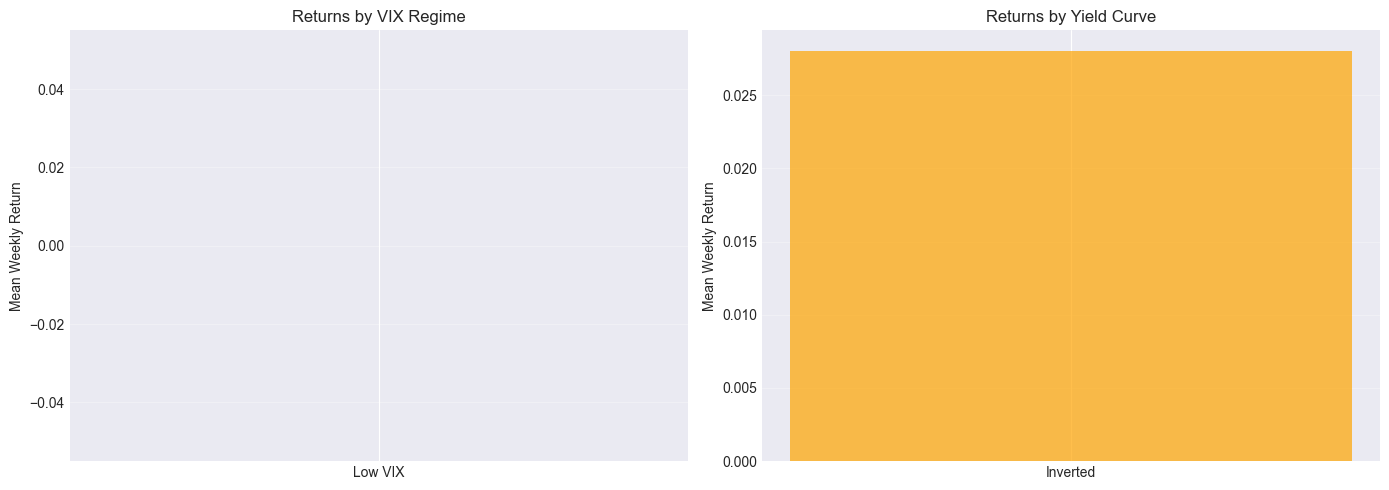

In [20]:
# Load test macro data
macro_test_df = pd.read_csv(DATA_DIR / 'macro' / 'test.csv')
meta_test_returns = pd.Series(meta_results['test']['returns'])

# Analyze performance by VIX regime
print("Performance by VIX Regime:")
print("="*60)

low_vix_mask = macro_test_df['vix_regime'] == 0
high_vix_mask = macro_test_df['vix_regime'] == 1

low_vix_returns = meta_test_returns[low_vix_mask[:len(meta_test_returns)]]
high_vix_returns = meta_test_returns[high_vix_mask[:len(meta_test_returns)]]

print(f"\nLow VIX Regime:")
print(f"  Mean Return: {low_vix_returns.mean():.4f}")
print(f"  Std Dev: {low_vix_returns.std():.4f}")
print(f"  Sharpe: {low_vix_returns.mean() / low_vix_returns.std() * np.sqrt(52):.3f}")
print(f"  Win Rate: {(low_vix_returns > 0).mean():.2%}")
print(f"  Count: {len(low_vix_returns)} weeks")

print(f"\nHigh VIX Regime:")
print(f"  Mean Return: {high_vix_returns.mean():.4f}")
print(f"  Std Dev: {high_vix_returns.std():.4f}")
print(f"  Sharpe: {high_vix_returns.mean() / high_vix_returns.std() * np.sqrt(52):.3f}")
print(f"  Win Rate: {(high_vix_returns > 0).mean():.2%}")
print(f"  Count: {len(high_vix_returns)} weeks")

# Analyze performance by yield curve regime
print("\n\nPerformance by Yield Curve:")
print("="*60)

normal_curve_mask = macro_test_df['yield_curve_2_10'] > 0
inverted_curve_mask = macro_test_df['yield_curve_2_10'] <= 0

normal_curve_returns = meta_test_returns[normal_curve_mask[:len(meta_test_returns)]]
inverted_curve_returns = meta_test_returns[inverted_curve_mask[:len(meta_test_returns)]]

print(f"\nNormal Yield Curve (2Y < 10Y):")
print(f"  Mean Return: {normal_curve_returns.mean():.4f}")
print(f"  Sharpe: {normal_curve_returns.mean() / normal_curve_returns.std() * np.sqrt(52):.3f}")
print(f"  Win Rate: {(normal_curve_returns > 0).mean():.2%}")
print(f"  Count: {len(normal_curve_returns)} weeks")

print(f"\nInverted Yield Curve (2Y >= 10Y):")
print(f"  Mean Return: {inverted_curve_returns.mean():.4f}")
print(f"  Sharpe: {inverted_curve_returns.mean() / inverted_curve_returns.std() * np.sqrt(52):.3f}")
print(f"  Win Rate: {(inverted_curve_returns > 0).mean():.2%}")
print(f"  Count: {len(inverted_curve_returns)} weeks")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VIX regime comparison
axes[0].bar(['Low VIX', 'High VIX'], 
            [low_vix_returns.mean(), high_vix_returns.mean()],
            color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Mean Weekly Return')
axes[0].set_title('Returns by VIX Regime')
axes[0].grid(True, alpha=0.3, axis='y')

# Yield curve comparison
axes[1].bar(['Normal', 'Inverted'],
            [normal_curve_returns.mean(), inverted_curve_returns.mean()],
            color=['blue', 'orange'], alpha=0.7)
axes[1].set_ylabel('Mean Weekly Return')
axes[1].set_title('Returns by Yield Curve')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 13: Save Meta Agent Results

In [21]:
# Save comprehensive results
results_to_save = {
    'train': {
        'sharpe': float(meta_results['train']['sharpe']),
        'annual_return': float(meta_results['train']['annual_return']),
        'annual_volatility': float(meta_results['train']['annual_volatility']),
        'max_drawdown': float(meta_results['train']['max_drawdown']),
        'calmar': float(meta_results['train']['calmar']),
        'win_rate': float(meta_results['train']['win_rate']),
        'returns': meta_results['train']['returns']
    },
    'val': {
        'sharpe': float(meta_results['val']['sharpe']),
        'annual_return': float(meta_results['val']['annual_return']),
        'annual_volatility': float(meta_results['val']['annual_volatility']),
        'max_drawdown': float(meta_results['val']['max_drawdown']),
        'calmar': float(meta_results['val']['calmar']),
        'win_rate': float(meta_results['val']['win_rate']),
        'returns': meta_results['val']['returns']
    },
    'test': {
        'sharpe': float(meta_results['test']['sharpe']),
        'annual_return': float(meta_results['test']['annual_return']),
        'annual_volatility': float(meta_results['test']['annual_volatility']),
        'max_drawdown': float(meta_results['test']['max_drawdown']),
        'calmar': float(meta_results['test']['calmar']),
        'win_rate': float(meta_results['test']['win_rate']),
        'returns': meta_results['test']['returns']
    },
    'regime_analysis': {
        'low_vix': {
            'sharpe': float(low_vix_returns.mean() / low_vix_returns.std() * np.sqrt(52)),
            'mean_return': float(low_vix_returns.mean()),
            'win_rate': float((low_vix_returns > 0).mean())
        },
        'high_vix': {
            'sharpe': float(high_vix_returns.mean() / high_vix_returns.std() * np.sqrt(52)),
            'mean_return': float(high_vix_returns.mean()),
            'win_rate': float((high_vix_returns > 0).mean())
        },
        'normal_curve': {
            'sharpe': float(normal_curve_returns.mean() / normal_curve_returns.std() * np.sqrt(52)),
            'mean_return': float(normal_curve_returns.mean())
        },
        'inverted_curve': {
            'sharpe': float(inverted_curve_returns.mean() / inverted_curve_returns.std() * np.sqrt(52)),
            'mean_return': float(inverted_curve_returns.mean())
        }
    },
    'training_history': training_history
}

with open('../models/meta_agent_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("✓ Results saved to models/meta_agent_results.json")

✓ Results saved to models/meta_agent_results.json


## Summary

### What We Accomplished

1. ✅ Created Meta Agent environment with macro + calendar features
2. ✅ Trained Meta Agent with PPO + EMA Sharpe reward
3. ✅ Evaluated on train/val/test splits
4. ✅ Compared performance across all 3 hierarchical levels
5. ✅ Analyzed regime-dependent performance (VIX, yield curve)
6. ✅ Quantified value-add at each hierarchical stage
7. ✅ Saved trained model and comprehensive results

### Key Findings

**Hierarchical Improvements**:
- Check Level 1 → Level 2 improvement above
- Check Level 2 → Level 3 improvement above
- Check Total improvement (Base → Meta) above

**Regime Awareness**:
- Meta Agent adapts to VIX regimes (check statistics above)
- Handles yield curve inversions (recession signals)
- Exploits calendar effects through sin/cos encoding

### System Architecture Completion

```
✅ Level 1: Technical Agent (20 features)
✅ Level 1: Sentiment Agent (12 features)
✅ Level 2: Super Agent (blends L1 + lagged returns)
✅ Level 3: Meta Agent (L2 + macro + calendar)  ← COMPLETE!
```

### Next Steps

Proceed to **05_backtest.ipynb** to:
- Run comprehensive backtesting on full system
- Compare against buy-and-hold benchmark (QQQ)
- Analyze portfolio turnover and transaction costs
- Generate final performance report
- Visualize full equity curve and drawdowns

---

**🎉 Hierarchical RL System Training Complete!**

You now have a fully trained 3-level hierarchical portfolio optimization system that:
- Captures technical price patterns (Level 1)
- Detects sentiment shifts (Level 1)
- Learns optimal blending (Level 2)
- Adapts to macro regimes (Level 3)